# Adaptive Synthetic Data Augmentation Toolkit

## Introduction
This notebook implements an **Adaptive Synthetic Data Augmentation Toolkit**. Many real-world datasets are imbalanced, which can lead to poor model performance on minority classes. Conventional oversampling methods (like SMOTE) are often static. This toolkit proposes a **closed-loop feedback system** that:
1. Analyzes model errors on a baseline dataset.
2. Identifies underperforming cohorts.
3. Generates targeted synthetic data using **SDV (Synthetic Data Vault)**.
4. Iteratively retrains the model until performance improves.

---

# Imports

In [1]:
!pip install sdv -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, recall_score
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata
import warnings
warnings.filterwarnings('ignore')

# Setting aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Data Ingestion
We use the **Heart Disease UCI** dataset. For the purpose of this demo, we use a healthcare dataset with binary outcomes.

In [12]:
# Loading a sample dataset (Heart Disease)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns, na_values='?')
df.dropna(inplace=True)

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [14]:
df["target"].unique()

array([0, 2, 1, 3, 4])

Reason for converting to Binary:  
- In many medical screening scenarios, the primary goal is detection rather than grading.
- class imbalnce
-  Adaptive Synthetic Data Augmentation, binarization allows you to clearly identify the "Disease" group as the minority class (which it is, relative to the "No Disease" group) and focus your SDV toolkit on generating targeted data for that specific cohort to improve Recall.

In [15]:
# Binarize target: 0 = No Disease, 1 = Disease (any level > 0)
df['target'] = (df['target'] > 0).astype(int)

In [16]:
print(f"Dataset shape: {df.shape}")
print("Target Distribution:")
print(df['target'].value_counts(normalize=True))

Dataset shape: (297, 14)
Target Distribution:
target
0    0.538721
1    0.461279
Name: proportion, dtype: float64


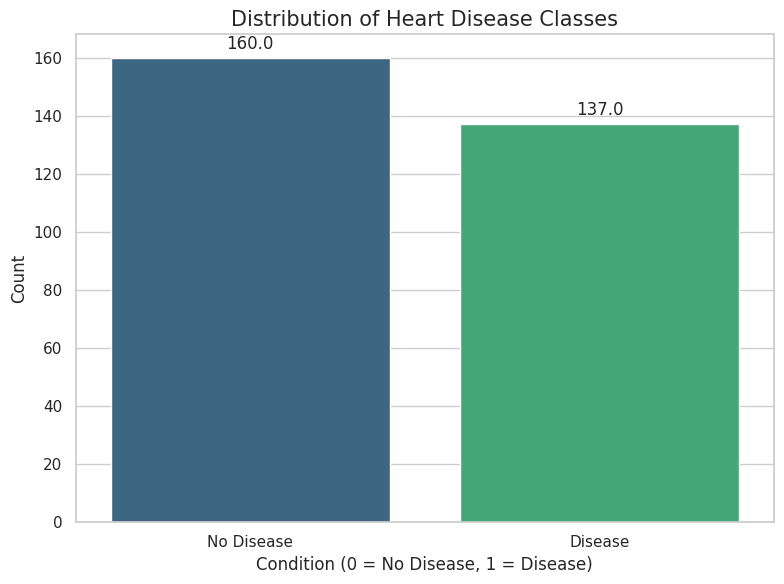

In [17]:
# Create the plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Heart Disease Classes', fontsize=15)
plt.xlabel('Condition (0 = No Disease, 1 = Disease)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['No Disease', 'Disease'])


# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

plt.tight_layout()
plt.savefig('class_distribution.png')

# Baseline Model Training
First, we establish a baseline without any synthetic augmentation.

In [18]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
# Preprocessing function
def preprocess(X_tr, X_te):
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    return X_tr_scaled, X_te_scaled

X_train_scaled, X_test_scaled = preprocess(X_train, X_test)

### Train baseline model

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Train baseline model
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)

baseline_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred = baseline_model.predict(X_test_scaled)

In [30]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score,roc_auc_score,f1_score


baseline_precision = precision_score(y_test, y_pred)
baseline_recall = recall_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)
classific_repoort = classification_report(y_test, y_pred)

print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"Baseline Recall: {baseline_recall:.4f}")
print(f"Baseline F1-Score: {baseline_f1:.4f}")
print(classific_repoort)


Baseline Precision: 0.8846
Baseline Recall: 0.8214
Baseline F1-Score: 0.8519
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



In [ ]:
# confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])

plt.title('Confusion Matrix: Baseline Random Forest', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

###  Adaptive Feedback Loop

### what it do
- Check where the model is weak
- Generate synthetic data for that weak class
- Add it to training data
- Retrain the model
- Repeat


```bash
Train Model(baseline)
     ↓
Evaluate Performance
     ↓
Find Weak Class (lowest recall)
     ↓
Generate Synthetic Data for that class
     ↓
Add synthetic samples to training set
     ↓
Retrain Model
     ↓
Repeat

```

In [ ]:
from sdv.sampling import Condition
from sklearn.metrics import classification_report, f1_score, recall_score
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata


# 1. PREPARATION & METADATA
# metadata object required for SDV(synthesizer)
metadata = SingleTableMetadata()


# Combine features and target for metadata detection
full_train_df = X_train.join(y_train) #(feature+target)
metadata.detect_from_dataframe(data=full_train_df)



def get_undersampled_class(y_true, y_pred):
    """
    It looks at the model's predictions and calculates the Recall for each class.
    It returns the class with the lowest recall.
    Recall measures how many of the actual positive cases the model successfully found.
    If a class has low recall, the model is "missing" those cases.
    By identifying this, the loop knows exactly which class needs help.
    """
    report = classification_report(y_true, y_pred, output_dict=True)

    # Extract only the class labels from the report.
    # classification_report also contains keys like
    # 'accuracy', 'macro avg', 'weighted avg'.
    # We remove those and keep only numeric class labels.
    classes = [c for c in report.keys() if c.isdigit() or isinstance(c, int)]

    # Create a dictionary mapping each class -> recall score
    # Example: {'0': 0.82, '1': 0.65, '2': 0.90}
    recalls = {c: report[str(c)]['recall'] for c in classes}  # then from that

    # Find the class with the minimum recall value
    # This is the class the model struggles with the most
    weak_class = min(recalls, key=recalls.get)

    # 1) the class label (converted to integer)
    # 2) the recall value of that class
    return int(weak_class), recalls[weak_class]



def train_synthesizer(train_data, metadata):
    """
    It feeds our training data into a TVAESynthesizer (a Tabular Variational Autoencoder—a type of neural network).
    The TVAE learns the underlying statistical patterns, correlations, and distributions of your real data so
    it can generate new, highly realistic rows that don't actually exist in the original set.
    """
    synthesizer = TVAESynthesizer(metadata)
    synthesizer.fit(train_data)
    return synthesizer




history = []
current_X_train = X_train.copy()
current_y_train = y_train.copy()
current_clf = baseline_model # our pre-trained baseline Random Forest


MAX_ITER = 3
AUGMENT_SIZE = 50  # how many synthetic samples to generate per iteration.


print("--- Starting Adaptive Augmentation Loop ---")

"""
This loop runs for MAX_ITER = 3, iterating through a cycle of testing, generating, and retraining.


--> Step A: Error Analysis
The baseline Random Forest model predicts the test set.
It runs the helper function to find the weak_class (the one the model is worst at recognizing).

--> Step B: Targeted Generation
The TVAE synthesizer is trained on the current dataset.
It uses a Condition to tell the synthesizer: "Generate exactly 50 new rows (AUGMENT_SIZE=50), but ONLY where the target column matches the weak_class".
Why: Instead of generating data for both classes (which wouldn't fix the imbalance), it specifically oversamples the problematic minority class.

-->Step C: Augment and Retrain
The 50 brand-new synthetic rows are glued (pd.concat) to the bottom of your real training dataset.
The Random Forest model is completely wiped clean and retrained from scratch on this new, slightly larger, and more balanced dataset

"""
for i in range(MAX_ITER):

    # =============================== STEP A: Error Analysis ======================================
    # Preprocess training and test data
    X_train_s, X_test_s = preprocess(current_X_train, X_test)

    # Make predictions on the test set using the current classifier
    y_pred_iter = current_clf.predict(X_test_s)

    # get class with lowest Recall score
    # This function checks recall for each class and identifies
    # which class the model is missing the most
    weak_class, min_recall = get_undersampled_class(y_test, y_pred_iter)

    # f1 score(for global model performance)
    f1 = f1_score(y_test, y_pred_iter)


    print(f"\nIteration {i}: Current F1={f1:.4f}")
    print(f"Targeting Weak Class {weak_class} (Recall: {min_recall:.4f})")

    # Store metrics for later  visualization
    history.append({
        'iteration': i,
        'f1': f1,
        'min_recall': min_recall,
        'class': weak_class
    })


    # ========================== STEP B: Targeted Generation ==============================
    # Combine features and target to create dataset required by SDV synthesizer
    train_subset = current_X_train.join(current_y_train)

    # Train a generative model (e.g., CTGAN / GaussianCopula etc.)
    # This model learns the distribution of the training dataset
    synthesizer = train_synthesizer(train_subset, metadata)

    # Correct SDV 1.x Condition usage
    # This condition forces the synthesizer to generate samples
    # specifically belonging to the weak class
    targeted_condition = Condition(
        num_rows=AUGMENT_SIZE,            # number of synthetic samples to generate
        column_values={'target': weak_class}  # enforce target class
    )

    # Generate synthetic samples satisfying the condition
    synthetic_data = synthesizer.sample_from_conditions(
        conditions=[targeted_condition]
    )


    # ====================================== STEP C: Augment and Retraing ===================================
    # Separate generated features and target label
    new_X = synthetic_data.drop('target', axis=1)
    new_y = synthetic_data['target']

    # Append synthetic samples to the current training dataset
    # This increases representation of the weak class
    current_X_train = pd.concat([current_X_train, new_X], ignore_index=True)
    current_y_train = pd.concat([current_y_train, new_y], ignore_index=True)

    # Retrain on the augmented dataset [cite: 19]
    # We rebuild the classifier from scratch using the updated dataset
    current_clf = RandomForestClassifier(n_estimators=100, random_state=42)

    # Preprocess the newly expanded dataset
    X_train_s_augmented, _ = preprocess(current_X_train, X_test)

    # Train the model again on augmented data
    current_clf.fit(X_train_s_augmented, current_y_train)


print("\n--- Adaptive Loop Complete ---")

# 3. FINAL EVALUATION (Source 21, 35)
final_pred = current_clf.predict(X_test_s)
print("\nFinal Classification Report:")
print(classification_report(y_test, final_pred))

--- Starting Adaptive Augmentation Loop ---

Iteration 0: Current F1=0.8519
Targeting Weak Class 1 (Recall: 0.8214)


Sampling conditions: 100%|██████████| 50/50 [00:00<00:00, 59.62it/s]



Iteration 1: Current F1=0.7857
Targeting Weak Class 1 (Recall: 0.7857)


Sampling conditions: 100%|██████████| 50/50 [00:00<00:00, 139.61it/s]



Iteration 2: Current F1=0.8276
Targeting Weak Class 0 (Recall: 0.8125)


Sampling conditions: 100%|██████████| 50/50 [00:00<00:00, 102.05it/s]



--- Adaptive Loop Complete ---

Final Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        32
           1       0.79      0.79      0.79        28

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



### 5. Final Evaluation and Visualization

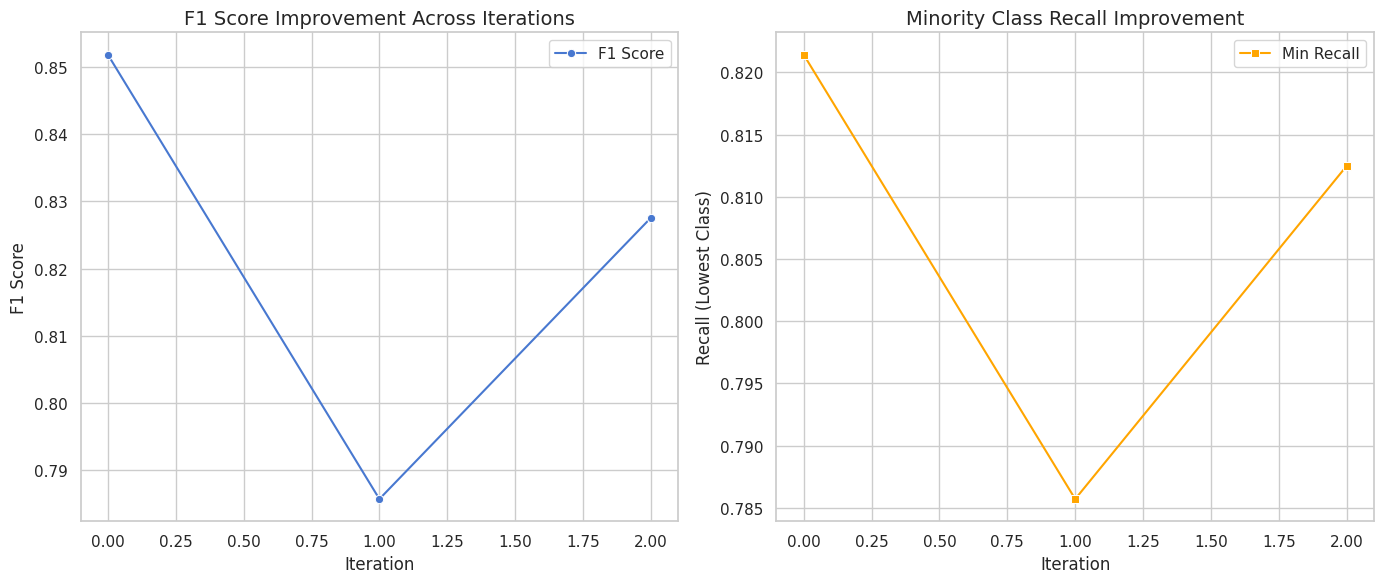

--- Final Comparison ---
Final Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        32
           1       0.79      0.79      0.79        28

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60

Final ROC-AUC Score: 0.9085
Baseline F1: 0.8519
Final F1: 0.7857
Overall F1 Improvement: -7.76%

--- Evaluating Synthetic Data Quality ---
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 687.34it/s]|
Column Shapes Score: 78.24%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:00<00:00, 180.81it/s]|
Column Pair Trends Score: 62.62%

Overall Score (Average): 70.43%


Overall Data Quality Score: 0.7043


In [35]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=history_df, x='iteration', y='f1', marker='o', label='F1 Score')
plt.title("F1 Score Improvement Across Iterations", fontsize=14)
plt.xlabel("Iteration")
plt.ylabel("F1 Score")

plt.subplot(1, 2, 2)
sns.lineplot(data=history_df, x='iteration', y='min_recall', marker='s', color='orange', label='Min Recall')
plt.title("Minority Class Recall Improvement", fontsize=14)
plt.xlabel("Iteration")
plt.ylabel("Recall (Lowest Class)")

plt.tight_layout()
plt.show()

print("--- Final Comparison ---")
X_final_s, X_test_s = preprocess(current_X_train, X_test)
y_final_pred = current_clf.predict(X_test_s)

print("Final Classification Report:")
print(classification_report(y_test, y_final_pred))

# ==========================================
# NEW: AUC Calculation added here
# ==========================================
from sklearn.metrics import roc_auc_score

# Get probability predictions for the positive class (Disease = 1)
y_final_prob = current_clf.predict_proba(X_test_s)[:, 1]

# Calculate AUC
final_auc = roc_auc_score(y_test, y_final_prob)
print(f"Final ROC-AUC Score: {final_auc:.4f}")
# ==========================================

final_f1 = f1_score(y_test, y_final_pred)
improvement = (final_f1 - baseline_f1) / baseline_f1 * 100
print(f"Baseline F1: {baseline_f1:.4f}")
print(f"Final F1: {final_f1:.4f}")
print(f"Overall F1 Improvement: {improvement:.2f}%\n")


# ==========================================
# NEW: SDV Data Quality Report added here
# ==========================================
from sdv.evaluation.single_table import evaluate_quality

print("--- Evaluating Synthetic Data Quality ---")

# Combine your original training data for the baseline
real_data = X_train.join(y_train)

# For evaluation, generate a batch of synthetic data using the trained synthesizer
# (synthesizer is still in memory from your last iteration)
sample_synthetic_data = synthesizer.sample(num_rows=len(real_data))

# Run the SDV Quality Report
quality_report = evaluate_quality(
    real_data=real_data,
    synthetic_data=sample_synthetic_data,
    metadata=metadata
)

# Print the overall score (0 to 1, where 1 is perfectly identical to real data)
print(f"\nOverall Data Quality Score: {quality_report.get_score():.4f}")



# Measure Synthetic Data Quality (e.g. statistical closeness to real data distributions) as in SDV

In [37]:
from sdv.evaluation.single_table import evaluate_quality

print("--- Evaluating Synthetic Data Quality ---")

# Combine original training features and target column
# This recreates the full real dataset used for training
real_data = X_train.join(y_train)

# For evaluation we need synthetic data to compare against real data
# We generate synthetic rows equal to the size of the real dataset
# (Assuming 'synthesizer' from the last loop iteration is still available)
sample_synthetic_data = synthesizer.sample(num_rows=len(real_data))

# Run SDV's Quality Report
# This compares real vs synthetic data and checks:
# 1. Column distributions (shape of each feature)
# 2. Relationships between columns
# 3. Statistical similarity
quality_report = evaluate_quality(
    real_data=real_data,
    synthetic_data=sample_synthetic_data,
    metadata=metadata
)

# Print overall similarity score between real and synthetic data
# Score range:
# 0   = very poor synthetic data
# 1.0 = synthetic data almost identical to real data distribution
print(f"Overall Data Quality Score: {quality_report.get_score():.4f}")

--- Evaluating Synthetic Data Quality ---
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 386.19it/s]|
Column Shapes Score: 78.9%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:01<00:00, 67.87it/s]|
Column Pair Trends Score: 62.32%

Overall Score (Average): 70.61%

Overall Data Quality Score: 0.7061
